In [1]:
from shared.main import * 
# subject_data = load_pickle("../../../analyses/lss_decision/subject_data_Schaefer100.pkl") 
# subject_data = load_pickle("../../../analyses/lss_decision/subject_data_Tavares.pkl") 
subject_data = load_pickle("../../../analyses/lss_decision/subject_data_Tavares_and_striatum_spheres.pkl")

## naively, theres only small variation across subjects in semantic regressors

In [7]:
def _as_subject_iter(subject_data):
    if isinstance(subject_data, dict):
        return list(subject_data.values())
    return list(subject_data)

def _unit_normalize_rows(X, eps=1e-12):
    X = np.asarray(X, float)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (norms + eps)

def _unit_normalize_vec(x, eps=1e-12):
    x = np.asarray(x, float)
    return x / (np.linalg.norm(x) + eps)

def _cosine_distance(a, b, eps=1e-12):
    a = _unit_normalize_vec(a, eps=eps)
    b = _unit_normalize_vec(b, eps=eps)
    return float(1.0 - np.dot(a, b))

def _mean_pairwise_cosine_distance(X):
    X = np.asarray(X, float)
    if X.shape[0] < 2:
        return 0.0
    return float(np.nanmean(pdist(_unit_normalize_rows(X), metric="cosine")))

def _centroid_dispersion(X, eps=1e-12):
    """
    Mean cosine distance of history embeddings from their running centroid.
    This is a compact estimate of semantic spread/dispersion.
    """
    X = _unit_normalize_rows(X, eps=eps)

    if X.shape[0] < 2:
        return 0.0

    centroid = _unit_normalize_vec(np.nanmean(X, axis=0), eps=eps)
    dists = 1.0 - (X @ centroid)
    return float(np.nanmean(dists))

def _find_char_col(df):
    if "character_role_num" in df.columns:
        return "character_role_num"
    if "char_role_num" in df.columns:
        return "char_role_num"
    raise KeyError("Could not find character column: expected character_role_num or char_role_num.")

def _ensure_character_decision_num(df, char_col="character_role_num"):
    """
    Add character_decision_num if missing.
    """
    out = df.copy()

    if "character_decision_num" not in out.columns:
        out["character_decision_num"] = (
            out.groupby(char_col).cumcount() + 1
        )

    return out

def add_within_character_semantic_features(
    behavior,
    embeddings,
    *,
    subject_id=None,
    char_col=None,
    x_col="character_decision_num",
    include_current=True,
    include_neutral=False,
    character_values=(1, 2, 3, 4, 5),
    embedding_label="embds_noctxt",
    eps=1e-12,
):
    """
    Add within-character semantic-history features to one subject's behavior dataframe.

    Parameters
    ----------
    behavior : pd.DataFrame
        Trialwise behavior dataframe.

    embeddings : array, shape n_trials × n_embedding_dims
        Trialwise embeddings aligned to behavior rows.

    include_current : bool
        If True, the current trial is included in the history.
        This makes the first same-character trial have approximately:
            semantic_runmean = 0
            semantic_dispersion = 0

        If False, features only use previous same-character trials.
        This makes the first same-character trial undefined/NaN.

    Returns
    -------
    pd.DataFrame
        Trialwise dataframe with semantic features.
    """

    if behavior is None or embeddings is None:
        return None

    beh = behavior.reset_index(drop=True).copy()
    E = np.asarray(embeddings, float)

    if len(beh) != E.shape[0]:
        raise ValueError(
            f"Behavior and embeddings do not align: behavior={len(beh)}, embeddings={E.shape[0]}"
        )

    if char_col is None:
        char_col = _find_char_col(beh)

    beh = _ensure_character_decision_num(beh, char_col=char_col)

    # Optionally remove neutral character.
    if not include_neutral:
        keep = beh[char_col].isin(character_values).to_numpy()
        beh = beh.loc[keep].reset_index(drop=True)
        E = E[keep]

    # Normalize embeddings once.
    E = _unit_normalize_rows(E, eps=eps)

    n = len(beh)

    semantic_runmean = np.full(n, np.nan)
    semantic_dispersion = np.full(n, np.nan)
    semantic_pairwise_dispersion = np.full(n, np.nan)
    semantic_history_norm = np.full(n, np.nan)
    n_semantic_history = np.zeros(n, dtype=int)

    # Compute features separately within each character.
    for char, idx in beh.groupby(char_col).groups.items():
        idx = np.asarray(list(idx), dtype=int)

        # Sort within character by character_decision_num.
        order = np.argsort(beh.loc[idx, x_col].to_numpy(float))
        idx = idx[order]

        for k, trial_idx in enumerate(idx):
            if include_current:
                hist_idx = idx[:k + 1]
            else:
                hist_idx = idx[:k]

            n_hist = len(hist_idx)
            n_semantic_history[trial_idx] = n_hist

            if n_hist == 0:
                continue

            hist_E = E[hist_idx]
            current_E = E[trial_idx]

            centroid_raw = np.nanmean(hist_E, axis=0)
            centroid_norm = np.linalg.norm(centroid_raw)
            centroid = centroid_raw / (centroid_norm + eps)

            semantic_runmean[trial_idx] = _cosine_distance(current_E, centroid, eps=eps)

            # Dispersion of the history around the centroid.
            semantic_dispersion[trial_idx] = _centroid_dispersion(hist_E, eps=eps)

            # Alternative dispersion: average pairwise distance among history items.
            semantic_pairwise_dispersion[trial_idx] = _mean_pairwise_cosine_distance(hist_E)

            # Norm of the unnormalized centroid.
            # High = history points in a consistent direction.
            # Low = semantically mixed/canceling history.
            semantic_history_norm[trial_idx] = float(centroid_norm)

    beh["sub_id"] = subject_id if subject_id is not None else beh.get("sub_id", np.nan)
    beh["embedding_label"] = embedding_label

    beh["n_semantic_history"] = n_semantic_history
    beh["semantic_runmean"] = semantic_runmean
    beh["semantic_dispersion"] = semantic_dispersion
    beh["semantic_pairwise_dispersion"] = semantic_pairwise_dispersion
    beh["semantic_history_norm"] = semantic_history_norm

    return beh

def build_sem_df_from_subject_data(
    subject_data,
    *,
    emb_key="embds_noctxt",
    include_current=True,
    include_neutral=False,
    character_values=(1, 2, 3, 4, 5),
    char_col=None,
    x_col="character_decision_num",
    verbose=True,
):
    """
    Build sem_df across all subjects.

    Returns
    -------
    sem_df : pd.DataFrame
        One row per subject × decision trial.
    """

    rows = []
    skipped = []

    for subj in _as_subject_iter(subject_data):
        if subj is None:
            continue

        sub_id = subj.get("sub_id", None)
        behavior = subj.get("behavior", None)
        embeddings = subj.get(emb_key, None)

        if behavior is None or embeddings is None:
            skipped.append((sub_id, "missing behavior or embeddings"))
            continue

        try:
            df_sub = add_within_character_semantic_features(
                behavior,
                embeddings,
                subject_id=sub_id,
                char_col=char_col,
                x_col=x_col,
                include_current=include_current,
                include_neutral=include_neutral,
                character_values=character_values,
                embedding_label=emb_key,
            )
        except Exception as e:
            skipped.append((sub_id, str(e)))
            continue

        if df_sub is not None and len(df_sub):
            rows.append(df_sub)

    sem_df = pd.concat(rows, axis=0, ignore_index=True) if rows else pd.DataFrame()

    if verbose:
        print(f"Built sem_df with {len(sem_df)} rows from {sem_df['sub_id'].nunique() if len(sem_df) else 0} subjects.")
        if skipped:
            print(f"Skipped {len(skipped)} subjects. First few:")
            print(skipped[:10])

    return sem_df

sem_df = build_sem_df_from_subject_data(
    subject_data,
    emb_key="embds_noctxt",       # or "embds_ctxt"
    include_current=True,
    include_neutral=False,
    character_values=(1, 2, 3, 4, 5),
    x_col="character_decision_num",
    verbose=True,
)


Built sem_df with 4020 rows from 67 subjects.


Built matrix: 4020 rows × 1536 embedding dims
Subjects: 67


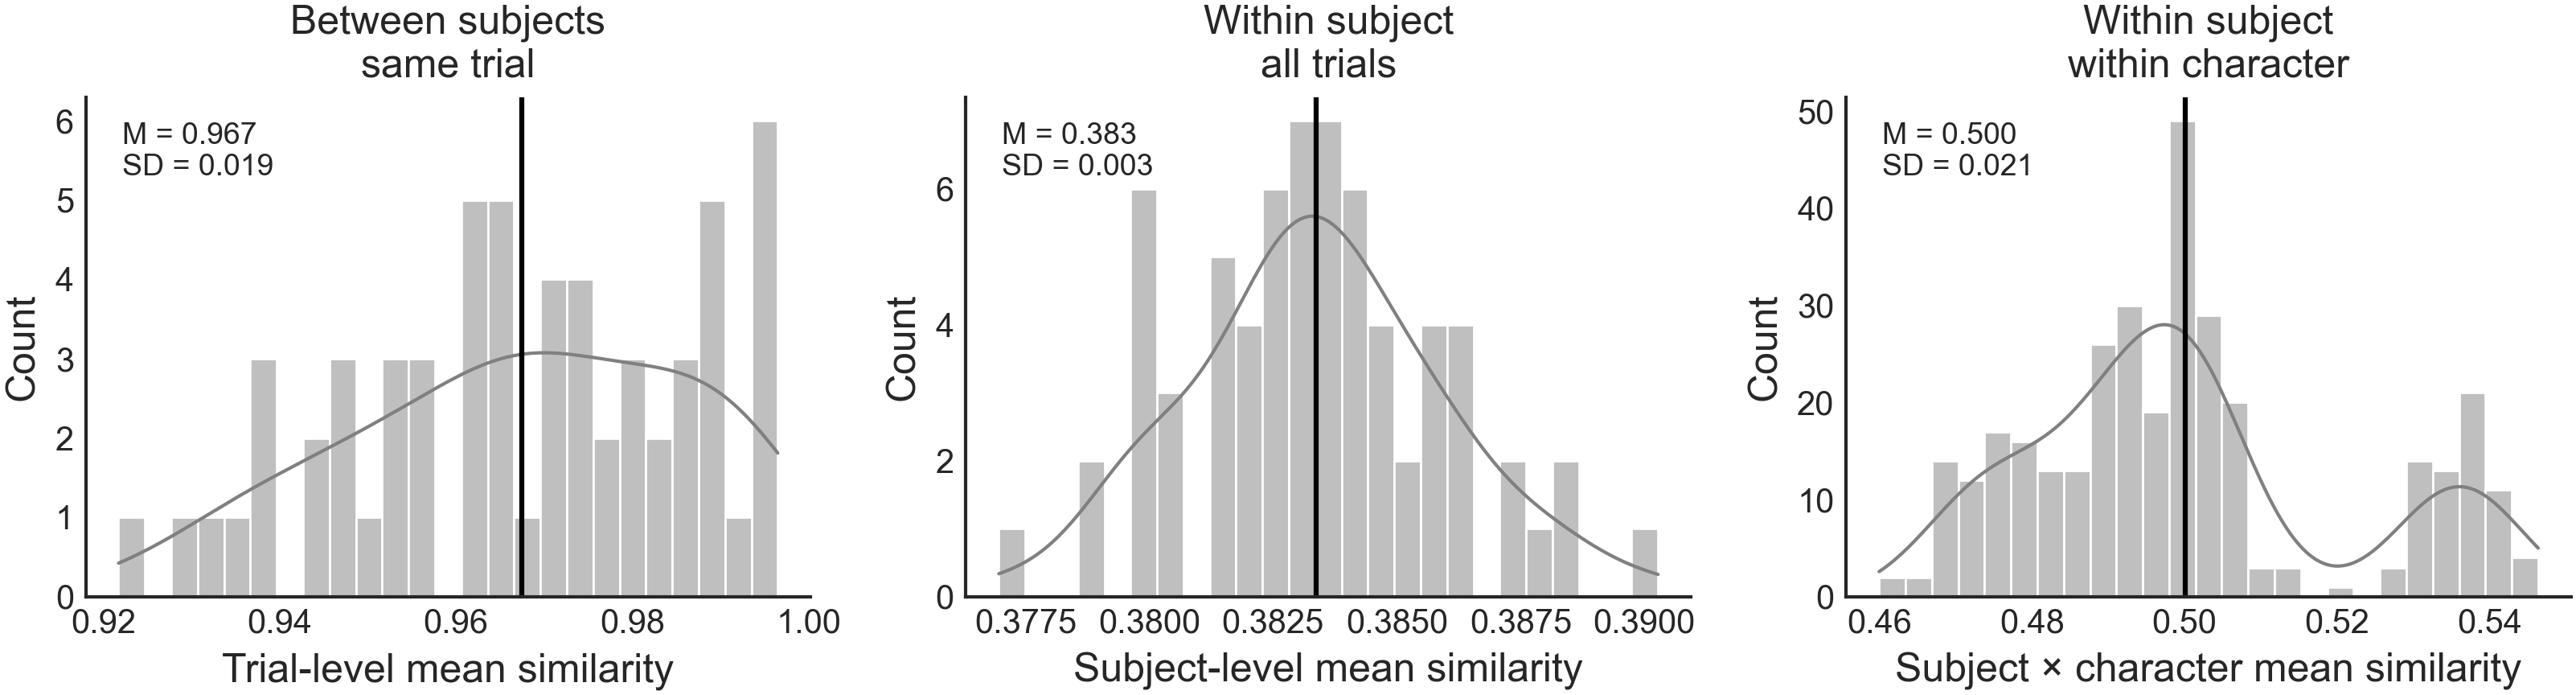

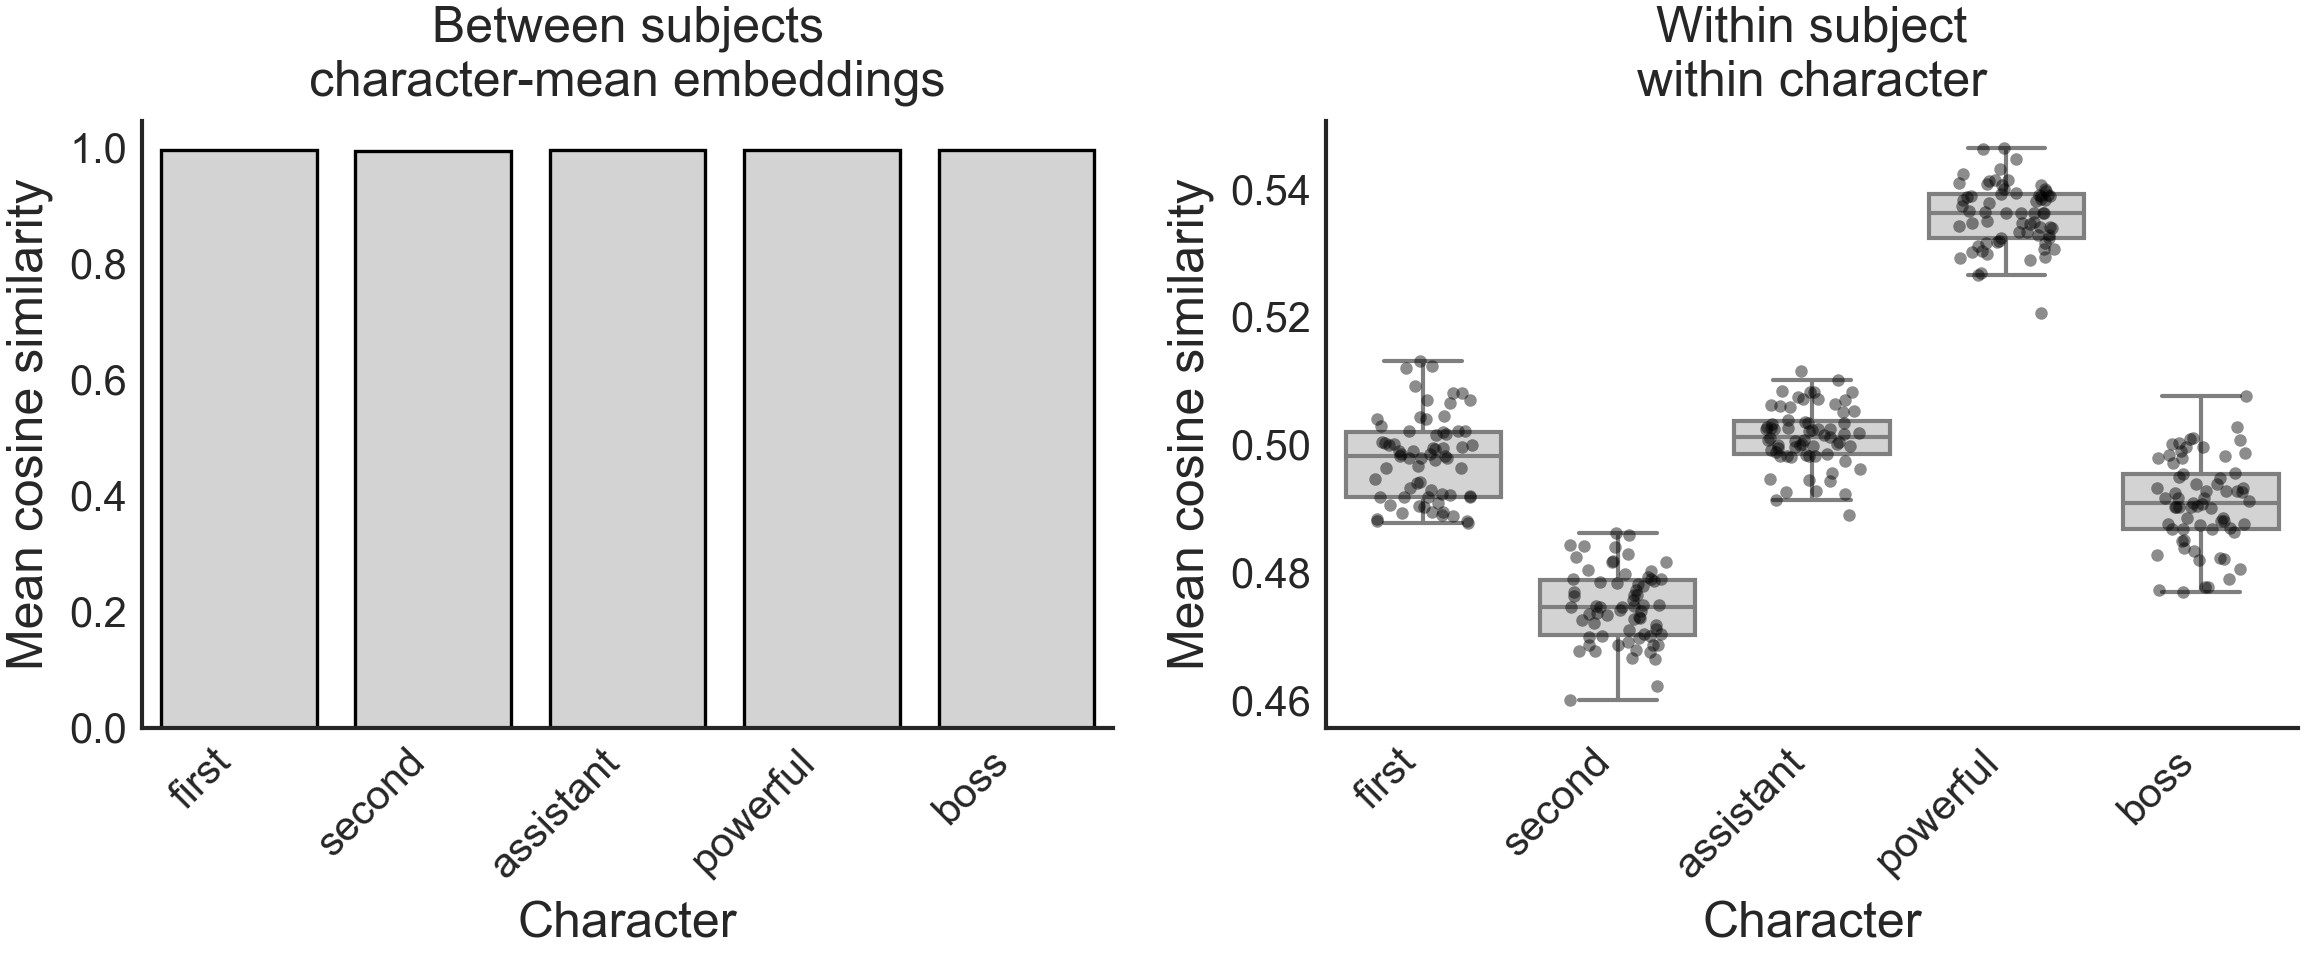

In [ ]:
def _as_subject_iter(subject_data):
    if isinstance(subject_data, dict):
        return list(subject_data.values())
    return list(subject_data)

def _find_char_col(df):
    if "character_role_num" in df.columns:
        return "character_role_num"
    if "char_role_num" in df.columns:
        return "char_role_num"
    raise KeyError("Could not find character column.")

def _unit_normalize_rows(X, eps=1e-12):
    X = np.asarray(X, float)
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)

def _mean_pairwise_cosine_similarity(X):
    """
    Mean pairwise cosine similarity among rows of X.
    """
    X = np.asarray(X, float)
    X = X[np.isfinite(X).all(axis=1)]

    if X.shape[0] < 2:
        return np.nan

    X = _unit_normalize_rows(X)
    return float(np.nanmean(1.0 - pdist(X, metric="cosine")))

def build_embedding_matrix_from_subject_data(
    subject_data,
    *,
    emb_key="embds_noctxt",
    include_neutral=False,
    character_values=(1, 2, 3, 4, 5),
    verbose=True,
):
    """
    Returns
    -------
    meta_df : pd.DataFrame
        One row per subject × trial.

    E : np.ndarray
        Embedding matrix aligned to meta_df rows.
    """

    meta_rows = []
    E_rows = []
    skipped = []

    for subj in _as_subject_iter(subject_data):
        if subj is None:
            continue

        sub_id = subj.get("sub_id", None)
        beh = subj.get("behavior", None)
        E = subj.get(emb_key, None)

        if beh is None or E is None:
            skipped.append((sub_id, "missing behavior or embeddings"))
            continue

        beh = beh.reset_index(drop=True).copy()
        E = np.asarray(E, float)

        if len(beh) != E.shape[0]:
            skipped.append((sub_id, f"trial mismatch: behavior={len(beh)}, embeddings={E.shape[0]}"))
            continue

        try:
            char_col = _find_char_col(beh)
        except Exception as e:
            skipped.append((sub_id, str(e)))
            continue

        if "character_decision_num" not in beh.columns:
            beh["character_decision_num"] = beh.groupby(char_col).cumcount() + 1

        if "decision_num" not in beh.columns:
            beh["decision_num"] = np.arange(len(beh)) + 1

        if not include_neutral:
            keep = beh[char_col].isin(character_values).to_numpy()
            beh = beh.loc[keep].reset_index(drop=True)
            E = E[keep]

        # keep minimal metadata
        keep_cols = [
            c for c in [
                "decision_num",
                "trial_num",
                "onset",
                char_col,
                "character_decision_num",
                "dimension",
                "choice",
                "choice_value",
                "reaction_time",
            ]
            if c in beh.columns
        ]

        meta = beh[keep_cols].copy()
        meta["sub_id"] = sub_id
        meta["emb_key"] = emb_key
        meta = meta.rename(columns={char_col: "character_role_num"})

        meta_rows.append(meta)
        E_rows.append(E)

    if len(meta_rows) == 0:
        raise RuntimeError("No usable subjects found.")

    meta_df = pd.concat(meta_rows, axis=0, ignore_index=True)
    E_all = np.vstack(E_rows)
    E_all = _unit_normalize_rows(E_all)

    if verbose:
        print(f"Built matrix: {E_all.shape[0]} rows × {E_all.shape[1]} embedding dims")
        print(f"Subjects: {meta_df['sub_id'].nunique()}")
        if skipped:
            print(f"Skipped {len(skipped)} subjects. First few:")
            print(skipped[:10])

    return meta_df, E_all

# ============================================================
# Between-subject similarity: same trial
# ============================================================

def summarize_between_subject_same_trial_similarity(
    meta_df,
    E,
    *,
    trial_cols=("character_role_num", "character_decision_num"),
    min_subjects=3,
):
    """
    For each matched trial, compute average pairwise similarity across subjects.

    This asks:
        For the same character decision, do participants have similar embeddings?
    """

    d = meta_df.copy()
    E = np.asarray(E, float)

    rows = []

    for trial_key, idx in d.groupby(list(trial_cols)).groups.items():
        idx = np.asarray(list(idx), dtype=int)

        sub_ids = d.loc[idx, "sub_id"].to_numpy()
        n_subjects = len(np.unique(sub_ids))

        if n_subjects < min_subjects:
            continue

        sims = 1.0 - pdist(E[idx], metric="cosine")

        if np.isfinite(sims).sum() == 0:
            continue

        if not isinstance(trial_key, tuple):
            trial_key = (trial_key,)

        row = dict(zip(trial_cols, trial_key))
        row.update({
            "n_subjects": n_subjects,
            "n_pairs": len(sims),
            "mean_similarity": float(np.nanmean(sims)),
            "median_similarity": float(np.nanmedian(sims)),
            "sd_similarity": float(np.nanstd(sims, ddof=1)),
        })

        rows.append(row)

    return pd.DataFrame(rows)

# ============================================================
# Between-subject similarity: subject × character average
# ============================================================

def summarize_between_subject_character_mean_similarity(
    meta_df,
    E,
    *,
    char_col="character_role_num",
    min_subjects=3,
):
    """
    First average embeddings within subject × character.
    Then compute pairwise similarity across subjects for each character.

    This asks:
        Do participants have similar average semantic representations for each character?
    """

    d = meta_df.copy()
    E = np.asarray(E, float)

    # subject × character average embeddings
    rows = []
    emb_rows = []

    for (sid, char), idx in d.groupby(["sub_id", char_col]).groups.items():
        idx = np.asarray(list(idx), dtype=int)
        emb = np.nanmean(E[idx], axis=0)
        emb = emb / (np.linalg.norm(emb) + 1e-12)

        rows.append({"sub_id": sid, char_col: char})
        emb_rows.append(emb)

    sc_meta = pd.DataFrame(rows)
    sc_E = np.vstack(emb_rows)

    out_rows = []

    for char, idx in sc_meta.groupby(char_col).groups.items():
        idx = np.asarray(list(idx), dtype=int)

        if len(idx) < min_subjects:
            continue

        sims = 1.0 - pdist(sc_E[idx], metric="cosine")

        out_rows.append({
            char_col: char,
            "n_subjects": len(idx),
            "n_pairs": len(sims),
            "mean_similarity": float(np.nanmean(sims)),
            "median_similarity": float(np.nanmedian(sims)),
            "sd_similarity": float(np.nanstd(sims, ddof=1)),
        })

    return pd.DataFrame(out_rows), sc_meta, sc_E

# ============================================================
# Within-subject similarity
# ============================================================

def summarize_within_subject_similarity(
    meta_df,
    E,
    *,
    char_col="character_role_num",
):
    """
    Compute within-participant embedding coherence.

    Returns:
      subject_all_df:
          one row per subject, similarity among all trials.

      subject_char_df:
          one row per subject × character, similarity among trials for that character.
    """

    d = meta_df.copy()
    E = np.asarray(E, float)

    subject_rows = []

    for sid, idx in d.groupby("sub_id").groups.items():
        idx = np.asarray(list(idx), dtype=int)

        subject_rows.append({
            "sub_id": sid,
            "n_trials": len(idx),
            "mean_similarity": _mean_pairwise_cosine_similarity(E[idx]),
        })

    subject_all_df = pd.DataFrame(subject_rows)

    subject_char_rows = []

    for (sid, char), idx in d.groupby(["sub_id", char_col]).groups.items():
        idx = np.asarray(list(idx), dtype=int)

        subject_char_rows.append({
            "sub_id": sid,
            char_col: char,
            "n_trials": len(idx),
            "mean_similarity": _mean_pairwise_cosine_similarity(E[idx]),
        })

    subject_char_df = pd.DataFrame(subject_char_rows)

    return subject_all_df, subject_char_df

# ============================================================
# Plots
# ============================================================

def plot_simple_embedding_similarity_histograms(
    between_trial_df,
    within_subject_df,
    within_subject_char_df,
    *,
    figsize=(11, 3.2),
    bins=25,
):
    """
    Three simple histograms:
      1. between-subject same-trial similarity
      2. within-subject all-trial similarity
      3. within-subject within-character similarity
    """

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    plot_info = [
        (
            between_trial_df["mean_similarity"],
            "Between subjects\nsame trial",
            "Trial-level mean similarity",
        ),
        (
            within_subject_df["mean_similarity"],
            "Within subject\nall trials",
            "Subject-level mean similarity",
        ),
        (
            within_subject_char_df["mean_similarity"],
            "Within subject\nwithin character",
            "Subject × character mean similarity",
        ),
    ]

    for ax, (vals, title, xlabel) in zip(axes, plot_info):
        vals = pd.to_numeric(vals, errors="coerce").to_numpy(float)
        vals = vals[np.isfinite(vals)]

        sns.histplot(vals, bins=bins, kde=True, color="gray", ax=ax)

        if len(vals):
            ax.axvline(np.mean(vals), color="black", lw=1.5)
            ax.text(
                0.05,
                0.95,
                f"M = {np.mean(vals):.3f}\nSD = {np.std(vals, ddof=1):.3f}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=9,
            )

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, axes

def plot_embedding_similarity_by_character(
    between_char_df,
    within_subject_char_df,
    *,
    char_col="character_role_num",
    char_labels=None,
    figsize=(8, 3.5),
):
    """
    Character-level view:
      left: between-subject similarity of character-mean embeddings
      right: within-subject within-character similarity
    """

    b = between_char_df.copy()
    w = within_subject_char_df.copy()

    if char_labels is not None:
        b["_char"] = b[char_col].map(char_labels).fillna(b[char_col].astype(str))
        w["_char"] = w[char_col].map(char_labels).fillna(w[char_col].astype(str))
        x_col = "_char"
    else:
        b["_char"] = b[char_col].astype(str)
        w["_char"] = w[char_col].astype(str)
        x_col = "_char"

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False)

    sns.barplot(
        data=b,
        x=x_col,
        y="mean_similarity",
        color="lightgray",
        edgecolor="black",
        ax=axes[0],
    )
    axes[0].set_title("Between subjects\ncharacter-mean embeddings")
    axes[0].set_xlabel("Character")
    axes[0].set_ylabel("Mean cosine similarity")

    sns.boxplot(
        data=w,
        x=x_col,
        y="mean_similarity",
        color="lightgray",
        showfliers=False,
        ax=axes[1],
    )
    sns.stripplot(
        data=w,
        x=x_col,
        y="mean_similarity",
        color="black",
        alpha=0.45,
        jitter=0.25,
        size=3,
        ax=axes[1],
    )
    axes[1].set_title("Within subject\nwithin character")
    axes[1].set_xlabel("Character")
    axes[1].set_ylabel("Mean cosine similarity")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, axes

# ============================================================
# Run it
# ============================================================

char_labels = {
    1: "first",
    2: "second",
    3: "assistant",
    4: "powerful",
    5: "boss",
}

meta_df, E = build_embedding_matrix_from_subject_data(
    subject_data,
    emb_key="embds_noctxt",       # or "embds_ctxt"
    include_neutral=False,
    character_values=(1, 2, 3, 4, 5),
)

between_trial_df = summarize_between_subject_same_trial_similarity(
    meta_df,
    E,
    trial_cols=("character_role_num", "character_decision_num"),
    min_subjects=3,
)

between_char_df, subject_char_meta, subject_char_E = summarize_between_subject_character_mean_similarity(
    meta_df,
    E,
    char_col="character_role_num",
    min_subjects=3,
)

within_subject_df, within_subject_char_df = summarize_within_subject_similarity(
    meta_df,
    E,
    char_col="character_role_num",
)

fig1, axes1 = plot_simple_embedding_similarity_histograms(
    between_trial_df,
    within_subject_df,
    within_subject_char_df,
    figsize=(11, 3.2),
    bins=25,
)

fig2, axes2 = plot_embedding_similarity_by_character(
    between_char_df,
    within_subject_char_df,
    char_col="character_role_num",
    char_labels=char_labels,
    figsize=(8, 3.5),
)

### it may be mostly trial identity

In [11]:
def make_rsa_rdvs(
    behavior,
    embeddings=None,
    *,
    rsa_covariates=(
        "dimension",
        "scene_num",
        "char_1", "char_2", "char_3", "char_4", "char_5",
        "character_decision_num",
        "choice",
        "semantic_choice",
        "location",
        "location_runmean",
        "location_dispersion",
        "semantic_runmean",
        "semantic_dispersion",
        "time",
        "time_sq",
        "reaction_time",
    ),
    role_values=(1, 2, 3, 4, 5),
    return_trial_features=False,
    eps=1e-12,
):
    """
    Build RSA RDVs from behavior + optional trialwise embeddings.

    Output:
        rdvs : dict[str, np.ndarray]
            Each value is a vectorized upper-triangle RDV with length T*(T-1)/2.

    Optional:
        if return_trial_features=True:
            returns (rdvs, trial_features)

    Main RDVs
    ---------
    Task structure:
      dimension:
          Binary distance between decision dimensions.
          0 = same dimension, 1 = different dimension.

      scene_num:
          Absolute difference in scene number.

      char_1 ... char_5:
          Character-specific same-character distance.
          For char_k: 0 = both trials are character k, 1 = otherwise.
          This matches the user's distance-coded wording.

      samechar_1 ... samechar_5:
          Compatibility alternative.
          For samechar_k: 1 = both trials are character k, 0 = otherwise.

      character:
          Generic character distance.
          0 = same character, 1 = different character.

      same_character:
          Generic same-character similarity.
          1 = same character, 0 = different character.

      character_decision_num:
          Absolute difference in within-character decision number.

    Choice-related:
      choice:
          Cosine distance between signed choice vectors:
          [affil_decision, power_decision].

      semantic_choice:
          Cosine distance between choice embeddings.

      choice_dispersion:
          Absolute difference in character-specific running choice-vector dispersion,
          computed after the current choice as mean cosine distance of prior/current
          choice vectors from the current running mean choice-vector direction.

    Social and semantic space:
      location:
          Euclidean distance between cumulative character-specific affiliation/power
          locations after the current choice.

      location_runmean:
          Euclidean distance between character-specific running mean affiliation/power
          states after the current choice.

      location_dispersion:
          Absolute difference in character-specific running spatial dispersion after
          the current choice, computed as RMS Euclidean distance of prior/current
          affiliation-power states from the current running mean state.

      semantic_runmean:
          Cosine distance between character-specific running mean choice embeddings
          after the current choice.

      semantic_dispersion:
          Absolute difference in character-specific running semantic dispersion after
          the current choice, computed as mean cosine distance of prior/current choice
          embeddings from the current running mean embedding.

    Nuisance:
      time:
          Absolute temporal distance between onsets.

      time_sq:
          Squared temporal distance between onsets: |onset_i - onset_j|^2.

      reaction_time:
          Absolute difference between reaction times.

    Compatibility aliases
    ---------------------
      dimension_diff             -> dimension
      semantic                   -> semantic_choice
      choice_vector              -> choice
      location_euclidean         -> location
      location_runmean_euclidean -> location_runmean
      semantic_content           -> semantic_runmean
      semantic_distance          -> semantic_dispersion
      time_linear / onset        -> time
      time_quadratic / onset_sq  -> time_sq
      different_character        -> character
      character_binary           -> character
      location_variability       -> choice_dispersion
      location_distance          -> choice_dispersion
    """

    # ---------------------------------------------------------------------
    # Basic setup
    # ---------------------------------------------------------------------

    b = behavior.copy().reset_index(drop=True)
    T = len(b)
    if T < 2:
        raise ValueError(f"Need at least 2 trials to make RDVs; got T={T}")

    ii, jj = np.triu_indices(T, k=1)
    n_pairs = len(ii)

    def _require_cols(cols, name):
        missing = [c for c in cols if c not in b.columns]
        if missing:
            raise KeyError(f"{name} requires missing behavior columns: {missing}")

    def _first_existing(candidates, name, required=True):
        for c in candidates:
            if c in b.columns:
                return c
        if required:
            raise KeyError(f"{name} requires one of these columns: {candidates}")
        return None

    def _num_col(candidates, name, required=True, default=None):
        c = _first_existing(candidates, name=name, required=required)
        if c is None:
            if default is None:
                return np.full(T, np.nan, float)
            return np.asarray(default, float)
        return pd.to_numeric(b[c], errors="coerce").to_numpy(float)

    def _pair_abs(x):
        x = np.asarray(x, float)
        out = np.abs(x[ii] - x[jj])
        out[~np.isfinite(x[ii]) | ~np.isfinite(x[jj])] = np.nan
        return out

    def _pair_sq_abs(x):
        d = _pair_abs(x)
        return d ** 2

    def _pair_cat_diff(x):
        s = pd.Series(x).reset_index(drop=True)
        codes, _ = pd.factorize(s, sort=True)
        codes = codes.astype(float)
        codes[codes < 0] = np.nan

        out = (codes[ii] != codes[jj]).astype(float)
        out[~np.isfinite(codes[ii]) | ~np.isfinite(codes[jj])] = np.nan
        return out

    def _pair_euclidean(X):
        X = np.asarray(X, float)
        if X.ndim != 2 or X.shape[0] != T:
            raise ValueError(f"Expected X to be T × D with T={T}; got {X.shape}")

        diff = X[ii] - X[jj]
        out = np.sqrt(np.nansum(diff ** 2, axis=1))
        ok = np.isfinite(X[ii]).all(axis=1) & np.isfinite(X[jj]).all(axis=1)
        out[~ok] = np.nan
        return out

    def _normalize_rows(X):
        X = np.asarray(X, float)
        U = np.full_like(X, np.nan, dtype=float)
        ok = np.isfinite(X).all(axis=1)
        norms = np.linalg.norm(X, axis=1)
        ok = ok & np.isfinite(norms) & (norms > eps)
        U[ok] = X[ok] / norms[ok, None]
        return U, ok

    def _pair_cosine(X):
        X = np.asarray(X, float)
        if X.ndim != 2 or X.shape[0] != T:
            raise ValueError(f"Expected X to be T × D with T={T}; got {X.shape}")

        U, ok = _normalize_rows(X)
        out = np.full(n_pairs, np.nan, dtype=float)

        ok_pair = ok[ii] & ok[jj]
        if ok_pair.any():
            sim = np.sum(U[ii[ok_pair]] * U[jj[ok_pair]], axis=1)
            out[ok_pair] = 1.0 - np.clip(sim, -1.0, 1.0)

        return out

    # ---------------------------------------------------------------------
    # Trialwise core variables
    # ---------------------------------------------------------------------

    role_col = _first_existing(
        ["character_role_num", "char_role_num"],
        name="character identity",
        required=True,
    )
    roles = pd.to_numeric(b[role_col], errors="coerce").to_numpy(float)

    # Choice vectors: signed 2D increments.
    _require_cols(["affil_decision", "power_decision"], "choice vectors")
    choice_vec = (
        b[["affil_decision", "power_decision"]]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(float)
    )

    # Dimension labels. Prefer explicit labels, otherwise infer from signed choice vector.
    dim_col = _first_existing(
        [
            "dimension",
            "decision_dimension",
            "trial_dimension",
            "choice_dimension",
            "decision_type",
            "trial_type",
        ],
        name="decision dimension",
        required=False,
    )
    if dim_col is not None:
        dimension = b[dim_col].astype(object).to_numpy()
    else:
        dimension = np.full(T, np.nan, dtype=object)
        a = choice_vec[:, 0]
        p = choice_vec[:, 1]
        dimension[np.isfinite(a) & (np.abs(a) > eps)] = "affiliation"
        dimension[np.isfinite(p) & (np.abs(p) > eps)] = "power"

    # Cumulative character-specific social-space locations after current choice.
    # If affil_coord/power_coord already exist, use them. Otherwise compute from decisions.
    if {"affil_coord", "power_coord"}.issubset(b.columns):
        location_state = (
            b[["affil_coord", "power_coord"]]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(float)
        )
    else:
        location_state = np.full((T, 2), np.nan, dtype=float)
        for r in pd.unique(pd.Series(roles).dropna()):
            idx = np.flatnonzero(roles == r)
            Xc = choice_vec[idx]
            location_state[idx] = np.cumsum(Xc, axis=0)

    # Within-character decision number. Prefer explicit, otherwise compute 1..n per character.
    if "character_decision_num" in b.columns:
        character_decision_num = pd.to_numeric(
            b["character_decision_num"], errors="coerce"
        ).to_numpy(float)
    else:
        character_decision_num = np.full(T, np.nan, dtype=float)
        for r in pd.unique(pd.Series(roles).dropna()):
            idx = np.flatnonzero(roles == r)
            character_decision_num[idx] = np.arange(1, len(idx) + 1, dtype=float)

    # Time. Prefer onset; otherwise use decision_num/trial_num/row number.
    time_col = _first_existing(
        ["onset", "decision_num", "trial_num"],
        name="time",
        required=False,
    )
    if time_col is not None:
        time = pd.to_numeric(b[time_col], errors="coerce").to_numpy(float)
    else:
        time = np.arange(T, dtype=float)

    # ---------------------------------------------------------------------
    # Running location statistics
    # ---------------------------------------------------------------------

    location_runmean_state = np.full((T, 2), np.nan, dtype=float)
    location_dispersion_value = np.full(T, np.nan, dtype=float)

    for r in pd.unique(pd.Series(roles).dropna()):
        idx = np.flatnonzero(roles == r)
        Xc = location_state[idx]

        for k, t_idx in enumerate(idx):
            Xk = Xc[: k + 1]
            ok = np.isfinite(Xk).all(axis=1)
            Xk = Xk[ok]

            if Xk.shape[0] == 0:
                continue

            mu = Xk.mean(axis=0)
            location_runmean_state[t_idx] = mu

            # RMS Euclidean spread around current running mean.
            # This is the spatial analogue of a running SD/radius.
            d = np.linalg.norm(Xk - mu, axis=1)
            location_dispersion_value[t_idx] = float(np.sqrt(np.mean(d ** 2)))

    # ---------------------------------------------------------------------
    # Running choice-vector dispersion
    # ---------------------------------------------------------------------
    # This is not the same as location_dispersion.
    # It measures directional variability of choice increments, not spread
    # of accumulated social-space states.

    choice_dispersion_value = np.full(T, np.nan, dtype=float)

    for r in pd.unique(pd.Series(roles).dropna()):
        idx = np.flatnonzero(roles == r)
        Xc = choice_vec[idx]

        for k, t_idx in enumerate(idx):
            Xk = Xc[: k + 1]
            U, ok = _normalize_rows(Xk)
            U = U[ok]

            if U.shape[0] == 0:
                continue
            if U.shape[0] == 1:
                choice_dispersion_value[t_idx] = 0.0
                continue

            mu = U.mean(axis=0)
            nmu = np.linalg.norm(mu)
            if not np.isfinite(nmu) or nmu <= eps:
                # If mean direction cancels perfectly, fallback to mean pairwise cosine distance.
                sims = U @ U.T
                tri = np.triu_indices(U.shape[0], k=1)
                choice_dispersion_value[t_idx] = float(
                    np.mean(1.0 - np.clip(sims[tri], -1.0, 1.0))
                )
            else:
                mu = mu / nmu
                sims = U @ mu
                choice_dispersion_value[t_idx] = float(
                    np.mean(1.0 - np.clip(sims, -1.0, 1.0))
                )

    # ---------------------------------------------------------------------
    # Running semantic statistics
    # ---------------------------------------------------------------------

    semantic_runmean_state = None
    semantic_dispersion_value = None

    if embeddings is not None:
        E = np.asarray(embeddings, float)
        if E.ndim != 2 or E.shape[0] != T:
            raise ValueError(
                f"embeddings must be trials × features with T={T}; got {E.shape}"
            )

        D = E.shape[1]
        semantic_runmean_state = np.full((T, D), np.nan, dtype=float)
        semantic_dispersion_value = np.full(T, np.nan, dtype=float)

        # Normalize trial embeddings first, then compute running semantic centroids.
        # This makes cosine dispersion interpretable.
        U_all, ok_all = _normalize_rows(E)

        for r in pd.unique(pd.Series(roles).dropna()):
            idx = np.flatnonzero(roles == r)

            for k, t_idx in enumerate(idx):
                idx_k = idx[: k + 1]
                Uk = U_all[idx_k]
                ok = ok_all[idx_k]
                Uk = Uk[ok]

                if Uk.shape[0] == 0:
                    continue

                mu = Uk.mean(axis=0)
                nmu = np.linalg.norm(mu)

                if not np.isfinite(nmu) or nmu <= eps:
                    continue

                mu = mu / nmu
                semantic_runmean_state[t_idx] = mu

                sims = Uk @ mu
                semantic_dispersion_value[t_idx] = float(
                    np.mean(1.0 - np.clip(sims, -1.0, 1.0))
                )

    # ---------------------------------------------------------------------
    # RDV builder
    # ---------------------------------------------------------------------

    aliases = {
        # old or alternate names -> new conceptual names
        "dimension_diff": "dimension",
        "semantic": "semantic_choice",
        "choice_vector": "choice",

        "location_euclidean": "location",
        "location_runmean_euclidean": "location_runmean",

        "semantic_content": "semantic_runmean",
        "semantic_distance": "semantic_dispersion",

        "time_linear": "time",
        "onset": "time",
        "time_quadratic": "time_sq",
        "onset_sq": "time_sq",

        "different_character": "character",
        "character_binary": "character",

        # old names that were really choice-vector variability
        "location_variability": "choice_dispersion",
        "location_distance": "choice_dispersion",
    }

    def _both_role_value(r):
        out = ((roles[ii] == r) & (roles[jj] == r)).astype(float)
        out[~np.isfinite(roles[ii]) | ~np.isfinite(roles[jj])] = np.nan
        return out

    def _make_one(cov):
        canonical = aliases.get(cov, cov)

        # -------------------------
        # Task structure
        # -------------------------

        if canonical == "dimension":
            return _pair_cat_diff(dimension)

        if canonical == "scene_num":
            x = _num_col(["scene_num"], name="scene_num", required=True)
            return _pair_abs(x)

        if canonical == "character_decision_num":
            return _pair_abs(character_decision_num)

        if canonical == "character":
            return _pair_cat_diff(roles)

        if canonical == "same_character":
            return 1.0 - _pair_cat_diff(roles)

        if canonical.startswith("char_"):
            # Distance-coded character-specific variable:
            # 0 = both trials are this character, 1 = otherwise.
            r = int(canonical.replace("char_", ""))
            return 1.0 - _both_role_value(r)

        if canonical.startswith("samechar_"):
            # Similarity/dummy-coded compatibility variable:
            # 1 = both trials are this character, 0 = otherwise.
            r = int(canonical.replace("samechar_", ""))
            return _both_role_value(r)

        # -------------------------
        # Choice-related
        # -------------------------

        if canonical == "choice":
            return _pair_cosine(choice_vec)

        if canonical == "semantic_choice":
            if embeddings is None:
                raise ValueError("embeddings is required for semantic_choice")
            return _pair_cosine(np.asarray(embeddings, float))

        if canonical == "choice_dispersion":
            return _pair_abs(choice_dispersion_value)

        # -------------------------
        # Social and semantic space
        # -------------------------

        if canonical == "location":
            return _pair_euclidean(location_state)

        if canonical == "location_runmean":
            return _pair_euclidean(location_runmean_state)

        if canonical == "location_dispersion":
            return _pair_abs(location_dispersion_value)

        if canonical == "semantic_runmean":
            if embeddings is None:
                raise ValueError("embeddings is required for semantic_runmean")
            return _pair_cosine(semantic_runmean_state)

        if canonical == "semantic_dispersion":
            if embeddings is None:
                raise ValueError("embeddings is required for semantic_dispersion")
            return _pair_abs(semantic_dispersion_value)

        # -------------------------
        # Nuisance covariates
        # -------------------------

        if canonical == "time":
            return _pair_abs(time)

        if canonical == "time_sq":
            return _pair_sq_abs(time)

        if canonical == "reaction_time":
            x = _num_col(
                ["reaction_time", "rt", "response_time"],
                name="reaction_time",
                required=True,
            )
            return _pair_abs(x)

        # -------------------------
        # Fallback: numeric behavior column
        # -------------------------

        if canonical in b.columns:
            x = pd.to_numeric(b[canonical], errors="coerce").to_numpy(float)
            return _pair_abs(x)

        raise ValueError(
            f"Unknown RSA covariate: {cov!r} "
            f"(canonicalized to {canonical!r})."
        )

    rdvs = {}

    for cov in rsa_covariates:
        if cov in {"char_dummies", "character_dummies"}:
            for r in role_values:
                rdvs[f"char_{int(r)}"] = _make_one(f"char_{int(r)}")
            continue

        if cov in {"samechar_dummies", "same_character_dummies"}:
            for r in role_values:
                rdvs[f"samechar_{int(r)}"] = _make_one(f"samechar_{int(r)}")
            continue

        rdvs[cov] = _make_one(cov)

    # ---------------------------------------------------------------------
    # Optional trialwise feature output for debugging
    # ---------------------------------------------------------------------

    if return_trial_features:
        trial_features = pd.DataFrame(
            {
                "character_role_num": roles,
                "dimension": dimension,
                "time": time,
                "character_decision_num": character_decision_num,
                "affil_decision": choice_vec[:, 0],
                "power_decision": choice_vec[:, 1],
                "affil_coord": location_state[:, 0],
                "power_coord": location_state[:, 1],
                "affil_runmean": location_runmean_state[:, 0],
                "power_runmean": location_runmean_state[:, 1],
                "location_dispersion": location_dispersion_value,
                "choice_dispersion": choice_dispersion_value,
            }
        )

        if semantic_dispersion_value is not None:
            trial_features["semantic_dispersion"] = semantic_dispersion_value

        return rdvs, trial_features

    return rdvs
    
def build_rdv_long_from_subject_data(
    subject_data,
    *,
    rsa_covariates,
    emb_key="embds_noctxt",
    subject_col="sub_id",
    verbose=True,
):
    """
    Builds a long dataframe of RSA regressors across subjects.

    Requires your existing make_rsa_rdvs() function.

    Output has one row per subject × trial-pair.
    """

    rows = []
    skipped = []

    subjects = list(subject_data.values()) if isinstance(subject_data, dict) else list(subject_data)

    for subj in subjects:
        if subj is None:
            continue

        sub_id = subj.get("sub_id", None)
        behavior = subj.get("behavior", None)
        embeddings = subj.get(emb_key, None)

        if behavior is None:
            skipped.append((sub_id, "missing behavior"))
            continue

        behavior = behavior.reset_index(drop=True)
        T = len(behavior)

        try:
            rdvs = make_rsa_rdvs(
                behavior,
                embeddings=embeddings,
                rsa_covariates=rsa_covariates,
            )
        except Exception as e:
            skipped.append((sub_id, str(e)))
            continue

        ii, jj = np.triu_indices(T, k=1)

        df = pd.DataFrame({
            "sub_id": sub_id,
            "i": ii,
            "j": jj,
            "pair_key": [f"{a}_{b}" for a, b in zip(ii, jj)],
        })

        # Add interpretable pair metadata if available.
        if "character_role_num" in behavior.columns:
            char = behavior["character_role_num"].to_numpy()
        elif "char_role_num" in behavior.columns:
            char = behavior["char_role_num"].to_numpy()
        else:
            char = None

        if char is not None:
            df["char_i"] = char[ii]
            df["char_j"] = char[jj]
            df["same_character"] = (char[ii] == char[jj]).astype(int)

        if "character_decision_num" in behavior.columns:
            cdn = behavior["character_decision_num"].to_numpy()
            df["char_decision_i"] = cdn[ii]
            df["char_decision_j"] = cdn[jj]

        if "decision_num" in behavior.columns:
            dec = behavior["decision_num"].to_numpy()
            df["decision_i"] = dec[ii]
            df["decision_j"] = dec[jj]
            df["lag"] = np.abs(dec[ii] - dec[jj])
        else:
            df["lag"] = np.abs(ii - jj)

        for cov in rsa_covariates:
            if cov in rdvs:
                df[cov] = np.asarray(rdvs[cov], float)

        rows.append(df)

    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

    if verbose:
        print(f"Built RDV long df: {len(out)} rows")
        print(f"Subjects: {out['sub_id'].nunique() if len(out) else 0}")
        if skipped:
            print(f"Skipped {len(skipped)} subjects. First few:")
            print(skipped[:10])

    return out

def decompose_rdv_regressor_variation(
    rdv_long_df,
    *,
    regressors,
    subject_col="sub_id",
    pair_col="pair_key",
):
    """
    Decomposes RSA regressor variation into pair/task structure vs subject structure.

    Key output:
      r2_pair:
          variance explained by fixed trial-pair identity

      unique_subject_after_pair:
          extra variance explained by subject after accounting for pair identity
    """

    rows = []

    for reg in regressors:
        if reg not in rdv_long_df.columns:
            continue

        d = rdv_long_df[[subject_col, pair_col, reg]].copy()
        d[reg] = pd.to_numeric(d[reg], errors="coerce")
        d = d.dropna()

        if len(d) < 10:
            continue

        y = d[reg].to_numpy(float)

        r2_pair = _r2_from_dummies(d, reg, [pair_col])
        r2_subject = _r2_from_dummies(d, reg, [subject_col])
        r2_both = _r2_from_dummies(d, reg, [pair_col, subject_col])

        pair_mean = d.groupby(pair_col)[reg].transform("mean")
        d["_pair_centered"] = d[reg] - pair_mean

        rows.append({
            "regressor": reg,
            "n_rows": len(d),
            "n_subjects": d[subject_col].nunique(),
            "n_pairs": d[pair_col].nunique(),

            "total_sd": float(np.nanstd(y, ddof=1)),
            "residual_sd_after_pair": float(np.nanstd(d["_pair_centered"], ddof=1)),

            "r2_pair": r2_pair,
            "r2_subject": r2_subject,
            "r2_pair_plus_subject": r2_both,

            "unique_subject_after_pair": (
                r2_both - r2_pair
                if np.isfinite(r2_both) and np.isfinite(r2_pair)
                else np.nan
            ),

            "residual_fraction_after_pair": (
                np.nanstd(d["_pair_centered"], ddof=1) / np.nanstd(y, ddof=1)
                if np.nanstd(y, ddof=1) > 1e-12
                else np.nan
            ),
        })

    return pd.DataFrame(rows)

rsa_covariates = [
    "semantic_runmean",
    "semantic_dispersion",
    "semantic_distance",
    "dimension_diff",
    "same_character",
    "time_linear",
    "time_quadratic",
]

rdv_long_df = build_rdv_long_from_subject_data(
    subject_data,
    rsa_covariates=rsa_covariates,
    emb_key="embds_noctxt",
)

rdv_variation = decompose_rdv_regressor_variation(
    rdv_long_df,
    regressors=rsa_covariates,
)

display(rdv_variation.round(3))

Built RDV long df: 130851 rows
Subjects: 67


,regressor,n_rows,n_subjects,n_pairs,total_sd,residual_sd_after_pair,r2_pair,r2_subject,r2_pair_plus_subject,unique_subject_after_pair,residual_fraction_after_pair
0,semantic_runmean,130851,67,1953,0.160,0.012,0.995,0.0,0.995,0.0,0.073
1,semantic_dispersion,130851,67,1953,0.081,0.006,0.995,0.0,0.995,0.0,0.071
2,semantic_distance,130851,67,1953,0.081,0.006,0.995,0.0,0.995,0.0,0.071
3,dimension_diff,130851,67,1953,0.497,0.000,1.000,0.0,1.000,0.0,0.000
4,same_character,130851,67,1953,0.376,0.000,1.000,0.0,1.000,0.0,0.000
5,time_linear,130851,67,1953,100.536,0.000,1.000,-0.0,1.000,0.0,0.000
6,time_quadratic,130851,67,1953,36573.359,0.000,1.000,0.0,1.000,0.0,0.000


In [18]:
def _make_design_matrix(df, cols, *, categorical_max_unique=12, add_intercept=True):
    """
    Build a numeric design matrix from mixed nuisance columns.

    Numeric columns with <= categorical_max_unique unique values are dummy-coded.
    Numeric continuous columns are z-scored.
    Object/category columns are dummy-coded.
    """

    if cols is None:
        cols = []

    cols = [c for c in cols if c in df.columns]

    parts = []

    if add_intercept:
        parts.append(pd.DataFrame({"Intercept": np.ones(len(df))}, index=df.index))

    for col in cols:
        x = df[col]

        # Treat object/category/bool as categorical
        if (
            x.dtype == "object"
            or str(x.dtype).startswith("category")
            or x.dtype == bool
        ):
            dum = pd.get_dummies(x.astype("category"), prefix=col, drop_first=True, dtype=float)
            if dum.shape[1] > 0:
                parts.append(dum)
            continue

        # Numeric
        xnum = pd.to_numeric(x, errors="coerce")
        nunique = xnum.nunique(dropna=True)

        if nunique <= 1:
            continue

        # Low-cardinality numeric nuisance: dummy-code
        if nunique <= categorical_max_unique:
            dum = pd.get_dummies(xnum.astype("category"), prefix=col, drop_first=True, dtype=float)
            if dum.shape[1] > 0:
                parts.append(dum)
            continue

        # Continuous nuisance: z-score
        mu = xnum.mean()
        sd = xnum.std(ddof=1)
        if np.isfinite(sd) and sd > 1e-12:
            parts.append(pd.DataFrame({col: (xnum - mu) / sd}, index=df.index))

    if len(parts) == 0:
        return np.empty((len(df), 0), float)

    X = pd.concat(parts, axis=1)
    return X.to_numpy(float)

def _ols_r2(y, X):
    y = np.asarray(y, float)
    X = np.asarray(X, float)

    ok = np.isfinite(y)
    if X.size:
        ok &= np.all(np.isfinite(X), axis=1)

    y = y[ok]
    X = X[ok]

    if len(y) < 5:
        return np.nan, np.full(len(ok), np.nan)

    if X.ndim == 1:
        X = X[:, None]

    if X.shape[1] == 0:
        X = np.ones((len(y), 1))

    if len(y) <= X.shape[1]:
        return np.nan, np.full(len(ok), np.nan)

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta

    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = 1 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan

    resid = np.full(len(ok), np.nan)
    resid[np.where(ok)[0]] = y - yhat

    return r2, resid

def _r2_for_formula_parts(df, y_col, *, nuisance=(), identity_cols=(), subject_col=None):
    """
    R2 for:
      y ~ nuisance + identity_cols + subject_col
    """

    cols = [y_col] + list(nuisance) + list(identity_cols)
    if subject_col is not None:
        cols.append(subject_col)

    cols = [c for c in cols if c in df.columns]

    d = df[cols].copy()
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna()

    if len(d) < 5 or d[y_col].std(ddof=1) < 1e-12:
        return np.nan, np.full(len(df), np.nan)

    rhs_cols = list(nuisance) + list(identity_cols)
    if subject_col is not None:
        rhs_cols.append(subject_col)

    X = _make_design_matrix(d, rhs_cols, add_intercept=True)
    r2, resid_local = _ols_r2(d[y_col].to_numpy(float), X)

    resid = pd.Series(np.nan, index=df.index, dtype=float)
    resid.loc[d.index] = resid_local

    return r2, resid.to_numpy(float)

def decompose_trialwise_semantic_variation_with_nuisance(
    sem_df,
    *,
    metrics=("semantic_runmean", "semantic_dispersion"),
    nuisance=(),
    subject_col="sub_id",
    char_col="character_role_num",
    trial_col="character_decision_num",
):
    """
    Nuisance-aware decomposition for trialwise semantic features.

    Models:
      y ~ nuisance
      y ~ nuisance + trial_identity
      y ~ nuisance + subject
      y ~ nuisance + trial_identity + subject

    Key outputs:
      r2_nuisance
      unique_trial_after_nuisance
      unique_subject_after_nuisance
      unique_subject_after_nuisance_trial
      residual_fraction_after_nuisance_trial
    """

    d = sem_df.copy()

    d["_trial_identity"] = (
        d[char_col].astype(str)
        + "_"
        + d[trial_col].astype(str)
    )

    rows = []

    for metric in metrics:
        if metric not in d.columns:
            continue

        dd = d.copy()
        dd[metric] = pd.to_numeric(dd[metric], errors="coerce")
        dd = dd.dropna(subset=[metric, subject_col, "_trial_identity"])

        if len(dd) < 10:
            continue

        y = dd[metric].to_numpy(float)
        raw_sd = np.nanstd(y, ddof=1)

        r2_nuis, resid_nuis = _r2_for_formula_parts(
            dd,
            metric,
            nuisance=nuisance,
            identity_cols=(),
            subject_col=None,
        )

        r2_nuis_trial, resid_nuis_trial = _r2_for_formula_parts(
            dd,
            metric,
            nuisance=nuisance,
            identity_cols=("_trial_identity",),
            subject_col=None,
        )

        r2_nuis_subject, resid_nuis_subject = _r2_for_formula_parts(
            dd,
            metric,
            nuisance=nuisance,
            identity_cols=(),
            subject_col=subject_col,
        )

        r2_nuis_trial_subject, resid_full = _r2_for_formula_parts(
            dd,
            metric,
            nuisance=nuisance,
            identity_cols=("_trial_identity",),
            subject_col=subject_col,
        )

        rows.append({
            "metric": metric,
            "n_rows": len(dd),
            "n_subjects": dd[subject_col].nunique(),
            "n_trials": dd["_trial_identity"].nunique(),

            "total_sd": raw_sd,

            "r2_nuisance": r2_nuis,
            "r2_nuisance_plus_trial": r2_nuis_trial,
            "r2_nuisance_plus_subject": r2_nuis_subject,
            "r2_nuisance_plus_trial_plus_subject": r2_nuis_trial_subject,

            "unique_trial_after_nuisance": (
                r2_nuis_trial - r2_nuis
                if np.isfinite(r2_nuis_trial) and np.isfinite(r2_nuis)
                else np.nan
            ),

            "unique_subject_after_nuisance": (
                r2_nuis_subject - r2_nuis
                if np.isfinite(r2_nuis_subject) and np.isfinite(r2_nuis)
                else np.nan
            ),

            "unique_subject_after_nuisance_trial": (
                r2_nuis_trial_subject - r2_nuis_trial
                if np.isfinite(r2_nuis_trial_subject) and np.isfinite(r2_nuis_trial)
                else np.nan
            ),

            "residual_sd_after_nuisance_trial": np.nanstd(resid_nuis_trial, ddof=1),

            "residual_fraction_after_nuisance_trial": (
                np.nanstd(resid_nuis_trial, ddof=1) / raw_sd
                if np.isfinite(raw_sd) and raw_sd > 1e-12
                else np.nan
            ),
        })

    return pd.DataFrame(rows)

def decompose_rdv_regressor_variation_with_nuisance(
    rdv_long_df,
    *,
    regressors,
    nuisance=(),
    subject_col="sub_id",
    pair_col="pair_key",
):
    """
    Nuisance-aware decomposition for RSA pairwise regressors.

    Models:
      y ~ nuisance
      y ~ nuisance + pair_identity
      y ~ nuisance + subject
      y ~ nuisance + pair_identity + subject
    """

    d = rdv_long_df.copy()

    rows = []

    for reg in regressors:
        if reg not in d.columns:
            continue

        dd = d.copy()
        dd[reg] = pd.to_numeric(dd[reg], errors="coerce")
        dd = dd.dropna(subset=[reg, subject_col, pair_col])

        if len(dd) < 10:
            continue

        y = dd[reg].to_numpy(float)
        raw_sd = np.nanstd(y, ddof=1)

        r2_nuis, resid_nuis = _r2_for_formula_parts(
            dd,
            reg,
            nuisance=nuisance,
            identity_cols=(),
            subject_col=None,
        )

        r2_nuis_pair, resid_nuis_pair = _r2_for_formula_parts(
            dd,
            reg,
            nuisance=nuisance,
            identity_cols=(pair_col,),
            subject_col=None,
        )

        r2_nuis_subject, resid_nuis_subject = _r2_for_formula_parts(
            dd,
            reg,
            nuisance=nuisance,
            identity_cols=(),
            subject_col=subject_col,
        )

        r2_nuis_pair_subject, resid_full = _r2_for_formula_parts(
            dd,
            reg,
            nuisance=nuisance,
            identity_cols=(pair_col,),
            subject_col=subject_col,
        )

        rows.append({
            "regressor": reg,
            "n_rows": len(dd),
            "n_subjects": dd[subject_col].nunique(),
            "n_pairs": dd[pair_col].nunique(),

            "total_sd": raw_sd,

            "r2_nuisance": r2_nuis,
            "r2_nuisance_plus_pair": r2_nuis_pair,
            "r2_nuisance_plus_subject": r2_nuis_subject,
            "r2_nuisance_plus_pair_plus_subject": r2_nuis_pair_subject,

            "unique_pair_after_nuisance": (
                r2_nuis_pair - r2_nuis
                if np.isfinite(r2_nuis_pair) and np.isfinite(r2_nuis)
                else np.nan
            ),

            "unique_subject_after_nuisance": (
                r2_nuis_subject - r2_nuis
                if np.isfinite(r2_nuis_subject) and np.isfinite(r2_nuis)
                else np.nan
            ),

            "unique_subject_after_nuisance_pair": (
                r2_nuis_pair_subject - r2_nuis_pair
                if np.isfinite(r2_nuis_pair_subject) and np.isfinite(r2_nuis_pair)
                else np.nan
            ),

            "residual_sd_after_nuisance_pair": np.nanstd(resid_nuis_pair, ddof=1),

            "residual_fraction_after_nuisance_pair": (
                np.nanstd(resid_nuis_pair, ddof=1) / raw_sd
                if np.isfinite(raw_sd) and raw_sd > 1e-12
                else np.nan
            ),
        })

    return pd.DataFrame(rows)

pairwise_nuisance = [
    "time_linear",
    "time_quadratic",
    "reaction_time",
    "dimension_diff",
    "same_character",
]

rdv_variation_nuis = decompose_rdv_regressor_variation_with_nuisance(
    rdv_long_df,
    regressors=[
        "semantic_runmean",
        "semantic_dispersion",
        "semantic_distance",
    ],
    nuisance=pairwise_nuisance,
    subject_col="sub_id",
    pair_col="pair_key",
)

display(rdv_variation_nuis.round(3))

,regressor,n_rows,n_subjects,n_pairs,total_sd,r2_nuisance,r2_nuisance_plus_pair,r2_nuisance_plus_subject,r2_nuisance_plus_pair_plus_subject,unique_pair_after_nuisance,unique_subject_after_nuisance,unique_subject_after_nuisance_pair,residual_sd_after_nuisance_pair,residual_fraction_after_nuisance_pair
0,semantic_runmean,130851,67,1953,0.160,0.675,0.995,0.675,0.995,0.320,0.0,0.0,0.012,0.073
1,semantic_dispersion,130851,67,1953,0.081,0.046,0.995,0.046,0.995,0.949,0.0,0.0,0.006,0.071
2,semantic_distance,130851,67,1953,0.081,0.046,0.995,0.046,0.995,0.949,0.0,0.0,0.006,0.071


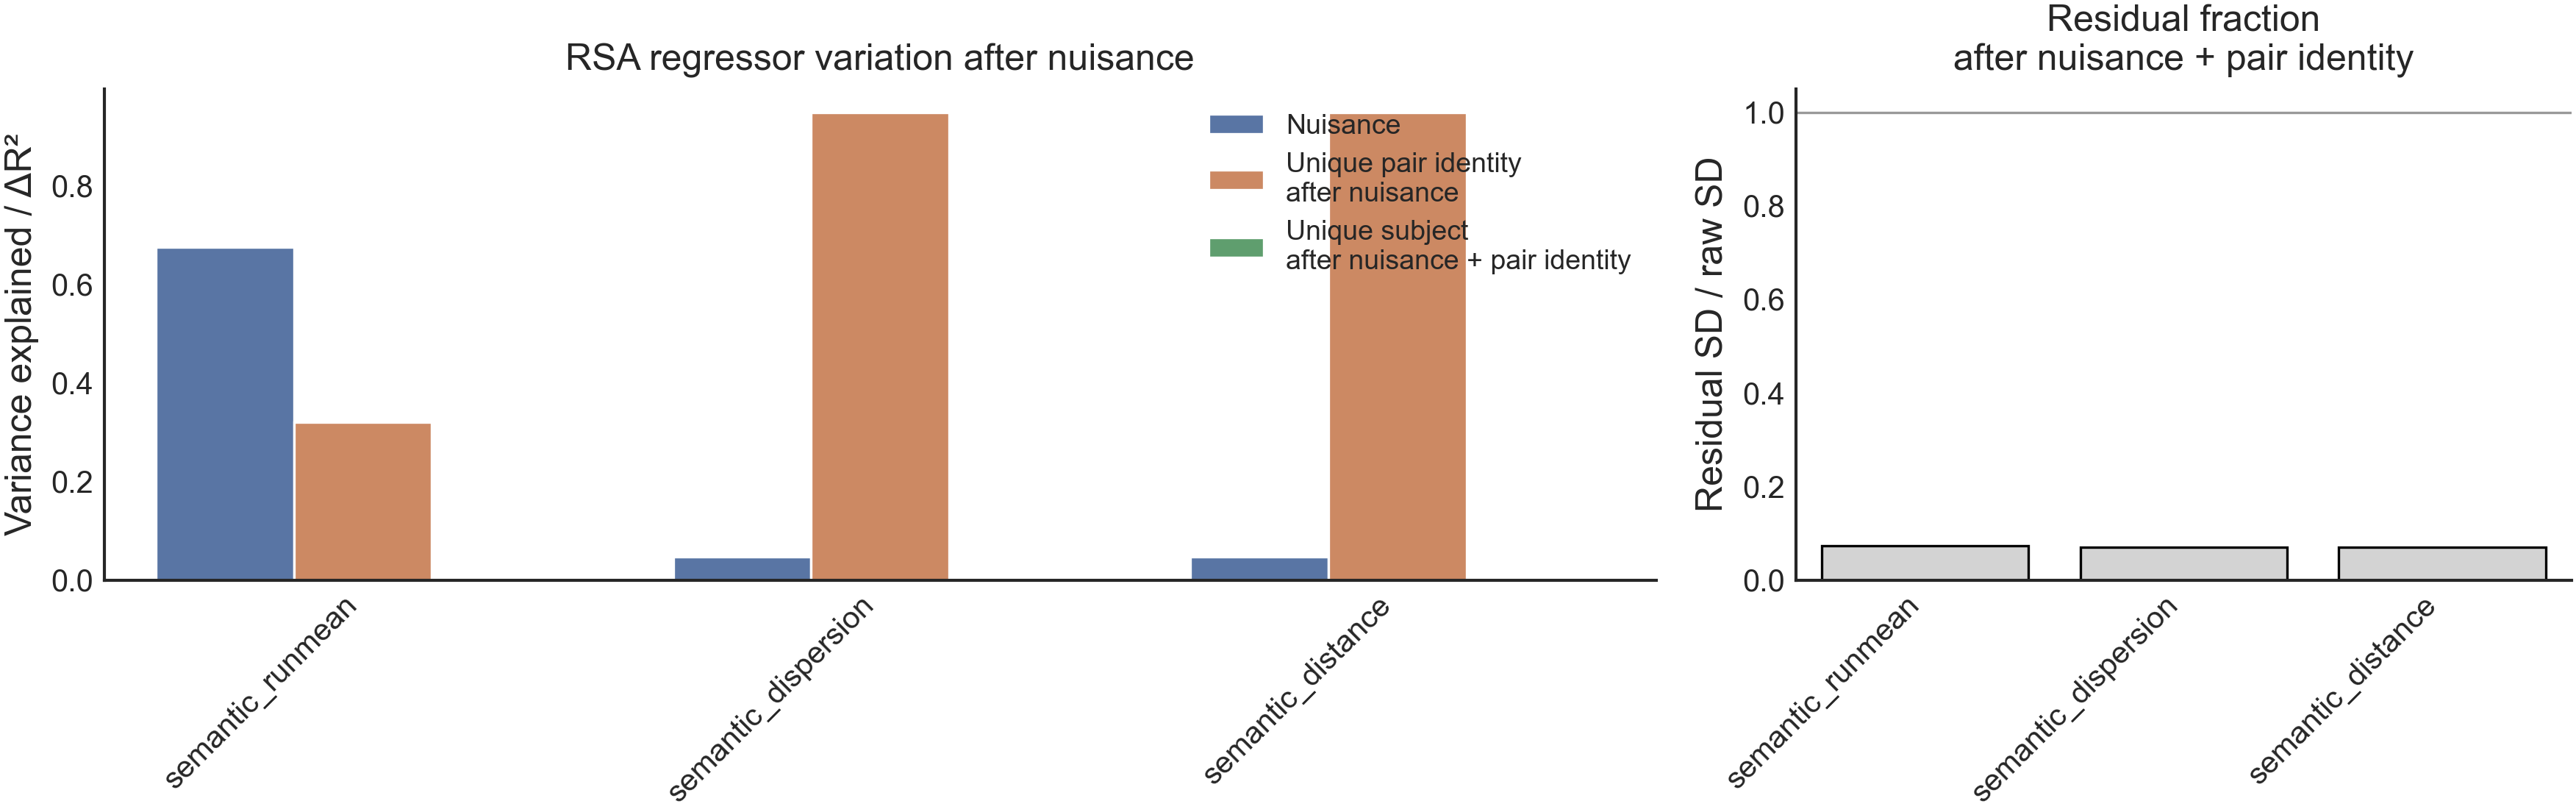

In [20]:
def plot_variation_decomposition_nuisance(
    variation_df,
    *,
    name_col,
    identity_label,
    title="Nuisance-aware variation decomposition",
    figsize=(11, 4),
):
    d = variation_df.copy()

    # Detect trialwise vs pairwise
    if "unique_trial_after_nuisance" in d.columns:
        unique_identity_col = "unique_trial_after_nuisance"
        unique_subject_col = "unique_subject_after_nuisance_trial"
        resid_col = "residual_fraction_after_nuisance_trial"
    elif "unique_pair_after_nuisance" in d.columns:
        unique_identity_col = "unique_pair_after_nuisance"
        unique_subject_col = "unique_subject_after_nuisance_pair"
        resid_col = "residual_fraction_after_nuisance_pair"
    else:
        raise ValueError("Could not detect trialwise or pairwise nuisance-aware columns.")

    keep = [
        name_col,
        "r2_nuisance",
        unique_identity_col,
        unique_subject_col,
        resid_col,
    ]
    d = d[keep].copy()

    long = d.melt(
        id_vars=name_col,
        value_vars=["r2_nuisance", unique_identity_col, unique_subject_col],
        var_name="component",
        value_name="r2",
    )

    label_map = {
        "r2_nuisance": "Nuisance",
        unique_identity_col: f"Unique {identity_label}\nafter nuisance",
        unique_subject_col: f"Unique subject\nafter nuisance + {identity_label}",
    }
    long["component"] = long["component"].map(label_map)

    fig, axes = plt.subplots(
        1, 2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [2, 1]},
    )

    sns.barplot(
        data=long,
        x=name_col,
        y="r2",
        hue="component",
        ax=axes[0],
    )

    axes[0].set_title(title)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Variance explained / ΔR²")
    axes[0].tick_params(axis="x", rotation=45)
    for tick in axes[0].get_xticklabels():
        tick.set_ha("right")
    axes[0].legend(title="", frameon=False)
    axes[0].axhline(0, color="black", lw=0.8, alpha=0.5)

    sns.barplot(
        data=d,
        x=name_col,
        y=resid_col,
        color="lightgray",
        edgecolor="black",
        ax=axes[1],
    )

    axes[1].set_title(f"Residual fraction\nafter nuisance + {identity_label}")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Residual SD / raw SD")
    axes[1].tick_params(axis="x", rotation=45)
    for tick in axes[1].get_xticklabels():
        tick.set_ha("right")
    axes[1].axhline(1, color="black", lw=0.8, alpha=0.4)
    axes[1].axhline(0, color="black", lw=0.8, alpha=0.4)

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, axes

fig_rdv_nuis, axes_rdv_nuis = plot_variation_decomposition_nuisance(
    rdv_variation_nuis,
    name_col="regressor",
    identity_label="pair identity",
    title="RSA regressor variation after nuisance",
    figsize=(12, 4),
)

## possible ways to correct

In [13]:
def add_leave_one_subject_pair_centered_regressors(
    rdv_long_df,
    *,
    regressors,
    subject_col="sub_id",
    pair_col="pair_key",
    suffix="_pair_centered_loo",
):
    """
    For each regressor, subtract the leave-one-subject-out same-pair mean.

    New column:
        regressor_pair_centered_loo

    Meaning:
        subject-specific deviation from the shared task/pair template.
    """

    out = rdv_long_df.copy()

    for reg in regressors:
        if reg not in out.columns:
            print(f"Skipping missing regressor: {reg}")
            continue

        x = pd.to_numeric(out[reg], errors="coerce")
        out[reg] = x

        pair_sum = out.groupby(pair_col)[reg].transform("sum")
        pair_n = out.groupby(pair_col)[reg].transform("count")

        # Leave-one-subject-out pair mean.
        mean_other = (pair_sum - out[reg]) / (pair_n - 1)

        centered_col = f"{reg}{suffix}"
        mean_col = f"{reg}_pair_mean_loo"

        out[mean_col] = mean_other
        out[centered_col] = out[reg] - mean_other

        # If only one subject contributes to a pair, undefined.
        out.loc[pair_n <= 1, centered_col] = np.nan

    return out

semantic_regs = [
    "semantic_runmean",
    "semantic_dispersion",
    "semantic_distance",
]

rdv_long_centered = add_leave_one_subject_pair_centered_regressors(
    rdv_long_df,
    regressors=semantic_regs,
    subject_col="sub_id",
    pair_col="pair_key",
)

rdv_long_centered[
    ["sub_id", "pair_key",
     "semantic_runmean", "semantic_runmean_pair_centered_loo",
     "semantic_dispersion", "semantic_dispersion_pair_centered_loo",
     "semantic_distance", "semantic_distance_pair_centered_loo"]
].head()

,sub_id,pair_key,semantic_runmean,semantic_runmean_pair_centered_loo,semantic_dispersion,semantic_dispersion_pair_centered_loo,semantic_distance,semantic_distance_pair_centered_loo
0,18001,0_1,0.072591,0.004106,0.072591,0.004106,0.072591,0.004106
1,18001,0_2,0.139961,0.010575,0.122393,0.003705,0.122393,0.003705
2,18001,0_3,0.153855,0.004046,0.161113,-0.000901,0.161113,-0.000901
3,18001,0_4,0.599982,0.052015,0.000000,0.000000,0.000000,0.000000
4,18001,0_5,0.562469,0.024763,0.159048,0.002967,0.159048,0.002967


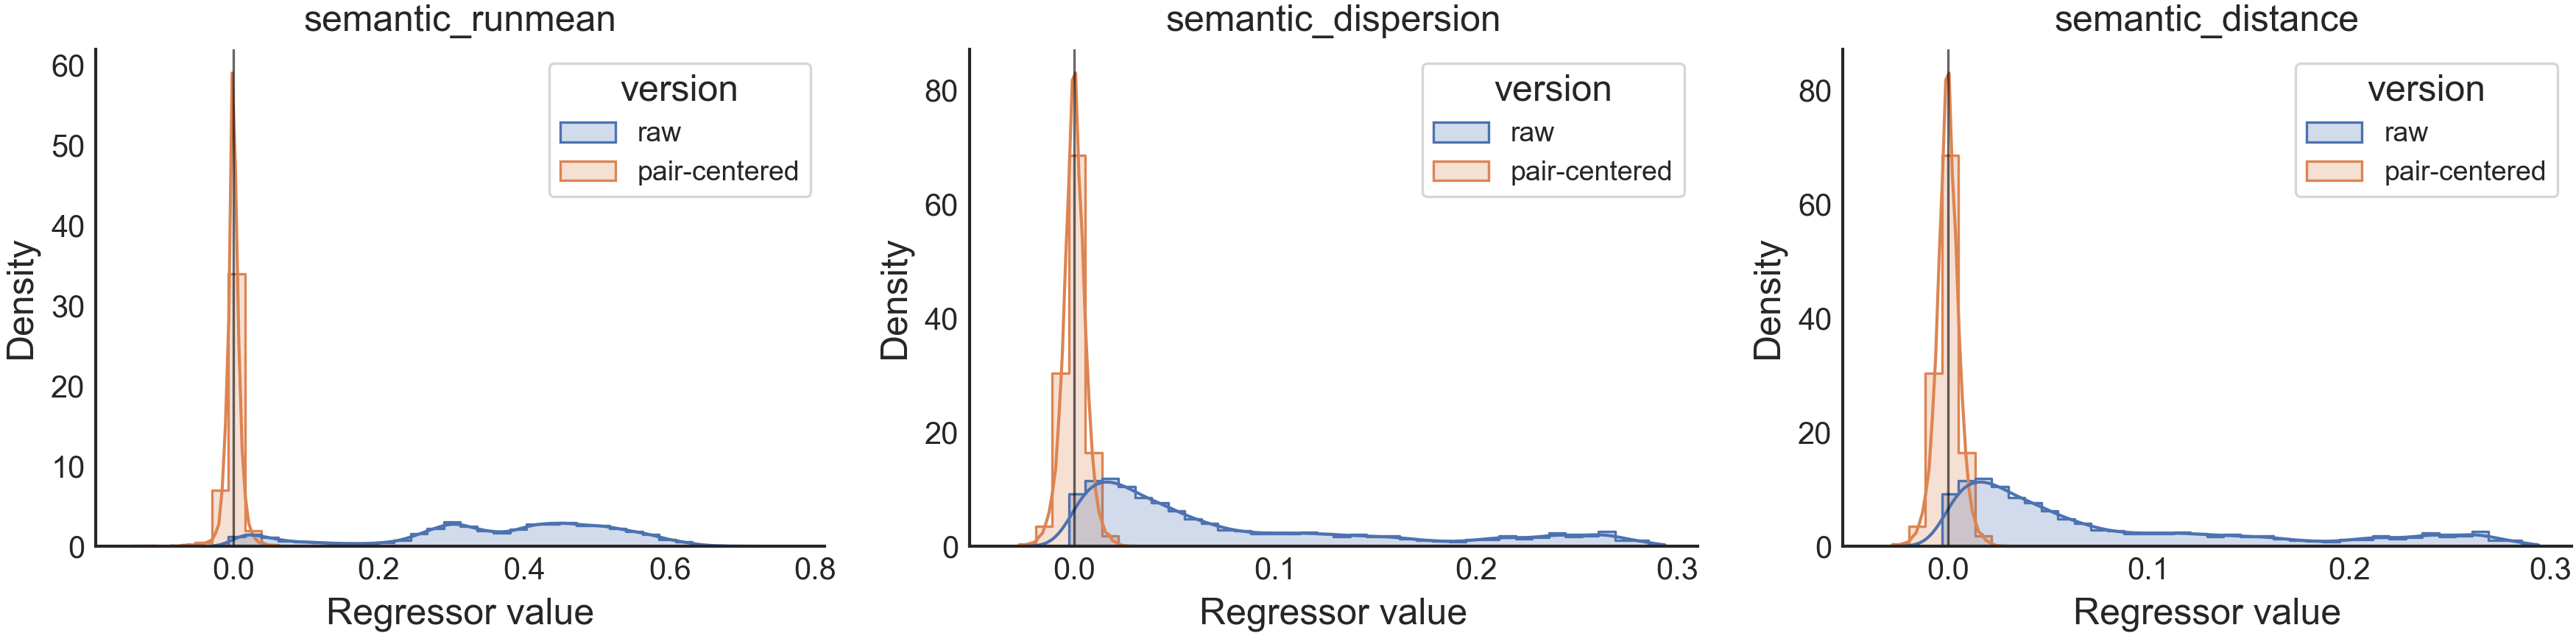

In [14]:
def plot_raw_vs_centered_rdv_distributions(
    rdv_long_centered,
    *,
    regressors=("semantic_runmean", "semantic_dispersion", "semantic_distance"),
    suffix="_pair_centered_loo",
    sample_n=100000,
    random_state=0,
    bins=40,
    figsize=None,
):
    d = rdv_long_centered.copy()

    if sample_n is not None and len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    rows = []

    for reg in regressors:
        centered = f"{reg}{suffix}"
        if reg not in d.columns or centered not in d.columns:
            continue

        tmp = d[[reg, centered]].copy()
        tmp = tmp.rename(columns={reg: "raw", centered: "pair-centered"})
        tmp = tmp.melt(var_name="version", value_name="value")
        tmp["regressor"] = reg
        rows.append(tmp)

    plot_df = pd.concat(rows, ignore_index=True)

    regs = plot_df["regressor"].unique()

    if figsize is None:
        figsize = (4.2 * len(regs), 3.2)

    fig, axes = plt.subplots(1, len(regs), figsize=figsize, squeeze=False)
    axes = axes[0]

    for ax, reg in zip(axes, regs):
        dd = plot_df[plot_df["regressor"] == reg].copy()

        sns.histplot(
            data=dd,
            x="value",
            hue="version",
            bins=bins,
            kde=True,
            stat="density",
            element="step",
            common_norm=False,
            ax=ax,
        )

        ax.axvline(0, color="black", lw=0.8, alpha=0.6)
        ax.set_title(reg)
        ax.set_xlabel("Regressor value")
        ax.set_ylabel("Density")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, axes

fig, axes = plot_raw_vs_centered_rdv_distributions(
    rdv_long_centered,
    regressors=semantic_regs,
    figsize=(12, 3.2),
)

In [15]:
def add_leave_one_subject_pair_centered_regressors(
    rdv_long_df,
    *,
    regressors,
    subject_col="sub_id",
    pair_col="pair_key",
    suffix="_pair_centered_loo",
):
    """
    For each regressor:
        centered value = subject value - same-pair mean among other subjects

    This removes the shared task/pair template while avoiding leakage from
    the subject into their own centering value.
    """

    out = rdv_long_df.copy()

    for reg in regressors:
        if reg not in out.columns:
            print(f"Skipping missing regressor: {reg}")
            continue

        out[reg] = pd.to_numeric(out[reg], errors="coerce")

        pair_sum = out.groupby(pair_col)[reg].transform("sum")
        pair_n = out.groupby(pair_col)[reg].transform("count")

        mean_other = (pair_sum - out[reg]) / (pair_n - 1)

        out[f"{reg}_pair_mean_loo"] = mean_other
        out[f"{reg}{suffix}"] = out[reg] - mean_other

        out.loc[pair_n <= 1, f"{reg}{suffix}"] = np.nan

    return out


semantic_regs = [
    "semantic_runmean",
    "semantic_dispersion",
    "semantic_distance",
]

rdv_long_centered = add_leave_one_subject_pair_centered_regressors(
    rdv_long_df,
    regressors=semantic_regs,
    subject_col="sub_id",
    pair_col="pair_key",
)

## can we find semantic features that track choices and vary more across subjects 